# MODELO PROPHET PARA EL CONTAMINANTE PM10 PARA SEVILLA

Importamos las librerías y definimos las rutas.

In [18]:
from pathlib import Path
from sklearn.model_selection import ParameterGrid

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("fbprophet").setLevel(logging.WARNING)

import matplotlib.pyplot as plt
from pylab import rcParams
plt.style.use("fivethirtyeight")
plt.rcParams["lines.linewidth"] = 1.5
light_style = {
    "figure.facecolor": "#d9effb",   
    "axes.facecolor": "#d9effb",
    "savefig.facecolor": "#d9effb",
    "axes.grid": True,
    "axes.grid.which": "both",
    "axes.spines.left": True,
    "axes.spines.right": True,
    "axes.spines.top": True,
    "axes.spines.bottom": True,
    "grid.color": "#a9d3f2",
    "grid.linewidth": "0.8",
    "text.color": "#333333",
    "axes.labelcolor": "#333333",
    "axes.labelweight": "black",      
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "font.size": 12,
    "axes.titleweight": "bold",      
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
}
plt.rcParams.update(light_style)
rcParams["figure.figsize"] = (18, 7)


import sys
import importlib
from pathlib import Path

SCRIPTS_PATH = Path.cwd().parents[2]

if str(SCRIPTS_PATH) not in sys.path:
    sys.path.append(str(SCRIPTS_PATH))

import utils

importlib.reload(utils)

from utils import CARGA_Y_FILTRO, GRAFICAR_ESTACIONALIDADES, EVALUAR_METRICAS, CALCULAR_VIF, BUSQUEDA_CONFIGURACIONES_PROPHET, ENTRENAR_EVALUAR_PROPHET

In [19]:
BASE_PATH = Path("..", "..", "..", "..")
FOLDER_FIGS = BASE_PATH / "figuras" / "Modelado" / "Sevilla"
FOLDER_FIGS.mkdir(parents=True, exist_ok=True)

Cargamos los datos y filtramos las columnas que realmente necesitamos y como ciudad elegimos únicamente Murcia.

In [20]:
df1 = CARGA_Y_FILTRO(
    contaminante="PM10 (ug.m-3)",
    ciudad="Sevilla"
)

## Análisis exploratorio de las estacionalidades

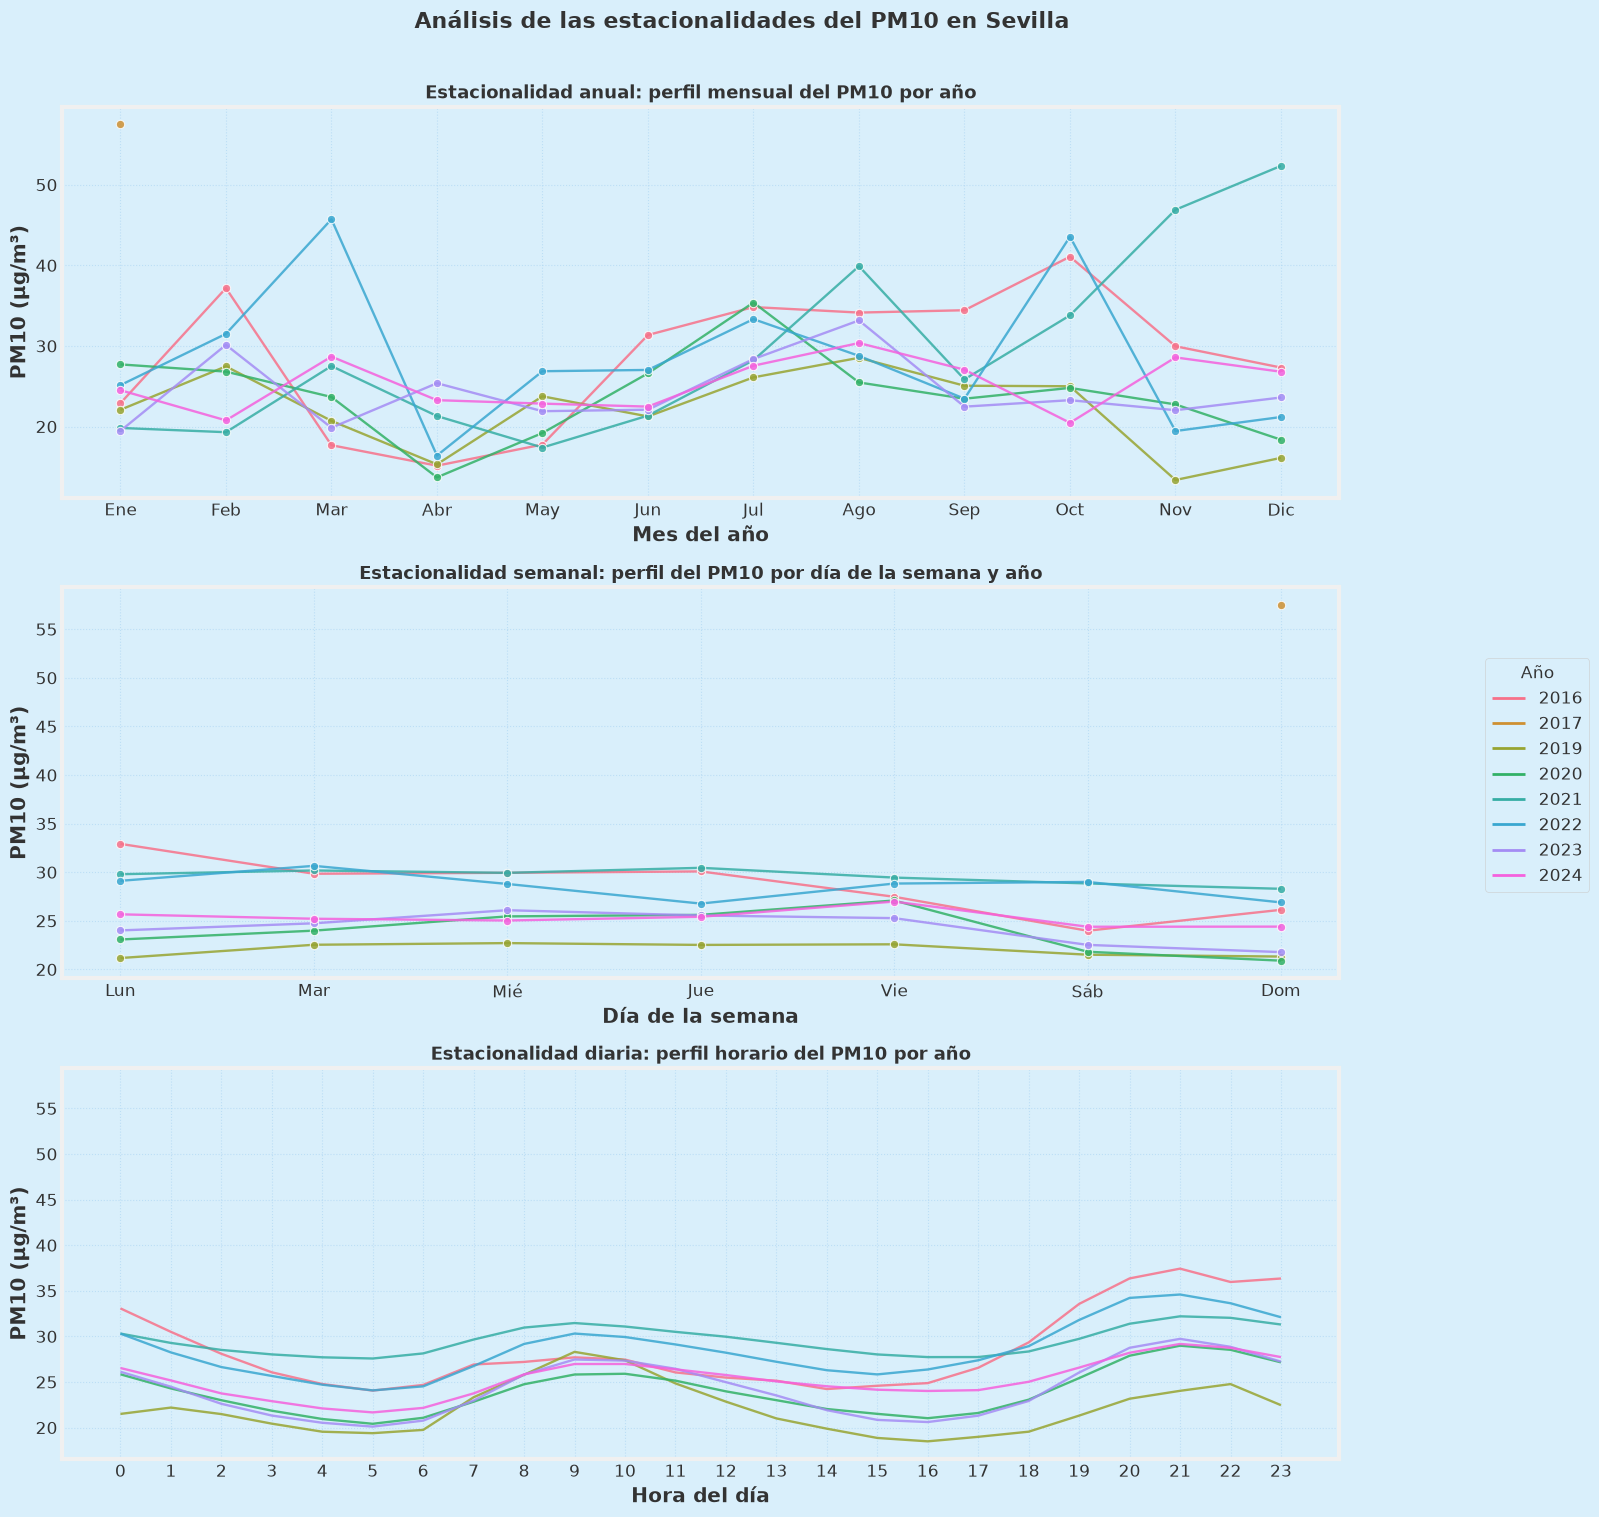

In [21]:
fig, axes = GRAFICAR_ESTACIONALIDADES(
    df=df1,
    contaminante='PM10 (ug.m-3)',
    ciudad="Sevilla",
    nombre_contaminante="PM10",
    unidad="µg/m³"
)

fig.savefig(
    FOLDER_FIGS / "estacionalidades_PM1O_Sevilla.png",
    dpi=300,                
    bbox_inches='tight',   
    facecolor='white'     
)

plt.show()

- Estacionalidad anual: no.
- Estacionalidad semanal: sí, cada 7 días.
- Estacionalidad diaria: sí, cada 24 horas.

## División del conjunto de datos

In [22]:
# ==============================================================================
# División cronológica del conjunto de datos
# ==============================================================================

train = df1[df1["Año"] <= 2022].copy()

validation = df1[
    (df1["Año"] >= 2023) &
    (df1["Año"] <= 2023)
].copy()

test = df1[df1["Año"] >= 2024].copy()

print(f"Entrenamiento: {train['Start'].min()} -> {train['Start'].max()}")
print(f"Validación:    {validation['Start'].min()} -> {validation['Start'].max()}")
print(f"Prueba:        {test['Start'].min()} -> {test['Start'].max()}")

print()
print(f"Nº muestras entrenamiento: {len(train):,}")
print(f"Nº muestras validación:    {len(validation):,}")
print(f"Nº muestras prueba:        {len(test):,}")

Entrenamiento: 2016-01-01 01:00:00 -> 2022-12-31 23:00:00
Validación:    2023-01-01 00:00:00 -> 2023-12-31 23:00:00
Prueba:        2024-01-01 00:00:00 -> 2024-12-31 23:00:00

Nº muestras entrenamiento: 43,814
Nº muestras validación:    8,760
Nº muestras prueba:        8,784


In [23]:
train = train.rename(columns={"Start": "ds", "PM10 (ug.m-3)": "y"})
validation = validation.rename(columns={"Start": "ds", "PM10 (ug.m-3)": "y"})
test = test.rename(columns={"Start": "ds", "PM10 (ug.m-3)": "y"})

## Elección de variables exógenas

In [24]:
multi = [
    "y",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "surface_pressure",
    "cloudcover",
    "windspeed_10m",
    "shortwave_radiation",
    "boundary_layer_height",
    "NDVI",
    "NDBI"
]

vif_exogenas = CALCULAR_VIF(
    datos=train,
    variables=multi
)

vif_exogenas

,variable,VIF
0,precipitation,inf
1,rain,inf
2,relative_humidity_2m,3.797605
3,boundary_layer_height,3.635734
4,shortwave_radiation,3.530012
5,temperature_2m,3.491033
6,surface_pressure,1.483446
7,windspeed_10m,1.387872
8,cloudcover,1.270481
9,NDBI,1.187120


In [25]:
multi1 = [
    "y",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "surface_pressure",
    "cloudcover",
    "windspeed_10m",
    "shortwave_radiation",
    "boundary_layer_height",
    "NDVI",
    "NDBI"
]

vif_exogenas1 = CALCULAR_VIF(
    datos=train,
    variables=multi1
)

vif_exogenas1

,variable,VIF
0,relative_humidity_2m,3.797605
1,boundary_layer_height,3.635734
2,shortwave_radiation,3.530012
3,temperature_2m,3.491033
4,surface_pressure,1.483446
5,windspeed_10m,1.387872
6,cloudcover,1.270481
7,NDBI,1.187120
8,precipitation,1.119782
9,y,1.087500


In [26]:
variables_exogenas1 = multi1.copy()
variables_exogenas1.remove("y")

## Selección de los mejores hiperparámetros

In [27]:
# Lista de columnas que quieres mantener
columnas = ['ds', 'y'] + variables_exogenas1

train = train[columnas]
validation = validation[columnas]

### Definición del espacio de búsqueda

In [28]:
# ==============================================================================
# Valores candidatos de los hiperparámetros
# ==============================================================================

param_grid = {
    
    # Flexibilidad de la tendencia
    "changepoint_prior_scale": [
        0.005,
        0.05,
        0.5
    ],

    # Parte inicial de la serie en la que se colocan los puntos de cambio
    "changepoint_range": [
        0.70,
        0.80,
        0.90
    ],

    # Intensidad de las estacionalidades
    "seasonality_prior_scale": [
        0.05,
        1.0
    ],

    # Tipo de estacionalidad
    "seasonality_mode": [
       "additive",
        "multiplicative"
    ],

    # Tipo de crecimiento
    "growth": [
       "linear",
        "logistic"
    ],

    # Número de términos de Fourier de la estacionalidad diaria
    "daily_seasonality": [
        5,
        10,
        20
    ],

    # Número de términos de Fourier de la estacionalidad semanal
    "weekly_seasonality": [
        5,
        10,
        20
    ],

    # Incorporación de festivos nacionales de España
    "usar_festivos": [
        False,
        True
    ]
}

### Búsqueda del mejor modelo

In [29]:
# ==============================================================================
# Límites para los modelos con crecimiento logístico
# ==============================================================================

capacidad = train["y"].max() * 1.20

print(
    "Capacidad utilizada para el crecimiento logístico: "
    f"{capacidad:.6f}"
)

# ==============================================================================
# Generación de todas las combinaciones posibles
# ==============================================================================

configuraciones = list(
    ParameterGrid(param_grid)
)

print(
    f"Número total de configuraciones que se evaluarán: "
    f"{len(configuraciones)}"
)

Capacidad utilizada para el crecimiento logístico: 826.488000
Número total de configuraciones que se evaluarán: 1296


In [ ]:
(
    resultados_df,
    resultados_correctos,
    mejor_resultado,
    mejor_modelo
) = BUSQUEDA_CONFIGURACIONES_PROPHET(
    configuraciones=configuraciones,
    variables_exogenas=variables_exogenas1,
    train=train,
    validation=validation,
    estacionalidades=[
        "yearly",
        "weekly",
        "daily"
    ],
    capacidad=capacidad
)

Estacionalidades utilizadas:
- weekly
- daily

Mejores parámetros:

changepoint_prior_scale: 0.5
changepoint_range: 0.7
seasonality_prior_scale: 1.0
seasonality_mode: multiplicative
growth: linear
usar_festivos: True
daily_seasonality: 20
weekly_seasonality: 20

MSE de validación: 164.114945


In [31]:
# Mejores parámetros obtenidos tras la búsqueda de hiperparámetros

mejores_parametros = {
    "changepoint_prior_scale": 0.5,
    "changepoint_range": 0.7,
    "seasonality_prior_scale": 1.0,
    "seasonality_mode": "multiplicative",
    "growth": "linear",
    "usar_festivos": True,
    "daily_seasonality": 20,
    "weekly_seasonality": 20
}

In [ ]:
(
    modelo_prophet,
    prediccion_validacion,
    metricas_validacion,
    train_prophet_final,
    validation_prophet_final
) = ENTRENAR_EVALUAR_PROPHET(
    train=train,
    validation=validation,
    variables_exogenas=variables_exogenas1,
    mejores_parametros=mejores_parametros
)

Resultados de la evaluación del modelo
---------------------------------------
Error absoluto medio (MAE): 0.596113
Error cuadrático medio (MSE): 164.114945
Raíz del error cuadrático medio (RMSE): 12.810736
Error porcentual absoluto medio (MAPE): 5.07 %
